In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

from utils.dataset_util import PATH_RAW_TRAINING_DATASET, PATH_RAW_TESTING_DATASET

In [2]:
training_set = pd.read_csv(PATH_RAW_TRAINING_DATASET)

In [3]:
# pre-processing
def preprocess(dataset):
    # Convert categorical 'yes' and 'no' columns to binary (1/0)
    categorical_cols = dataset.select_dtypes(include=['str']).columns
    print(f"Categorical Columns: {list(categorical_cols)}")

    for col in categorical_cols:
        if col != 'furnishingstatus':  # Handle this one separately
            dataset[col] = dataset[col].map({'yes': 1, 'no': 0})

    # 'furnishingstatus' has 3 unique values: furnished, semi-furnished, unfurnished
    # Apply One-Hot Encoding
    return pd.get_dummies(dataset, columns=['furnishingstatus'], drop_first=True, dtype=int)

In [4]:
training_set = preprocess(dataset=training_set)
training_set.head()

Categorical Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7525000,6000,3,2,4,1,0,0,0,1,1,0,0,0
1,6300000,7200,3,2,1,1,0,1,0,1,3,0,1,0
2,3920000,3816,2,1,1,1,0,1,0,1,2,0,0,0
3,3430000,2610,3,1,2,1,0,1,0,0,0,1,0,1
4,3010000,3750,3,1,2,1,0,0,0,0,0,0,0,1


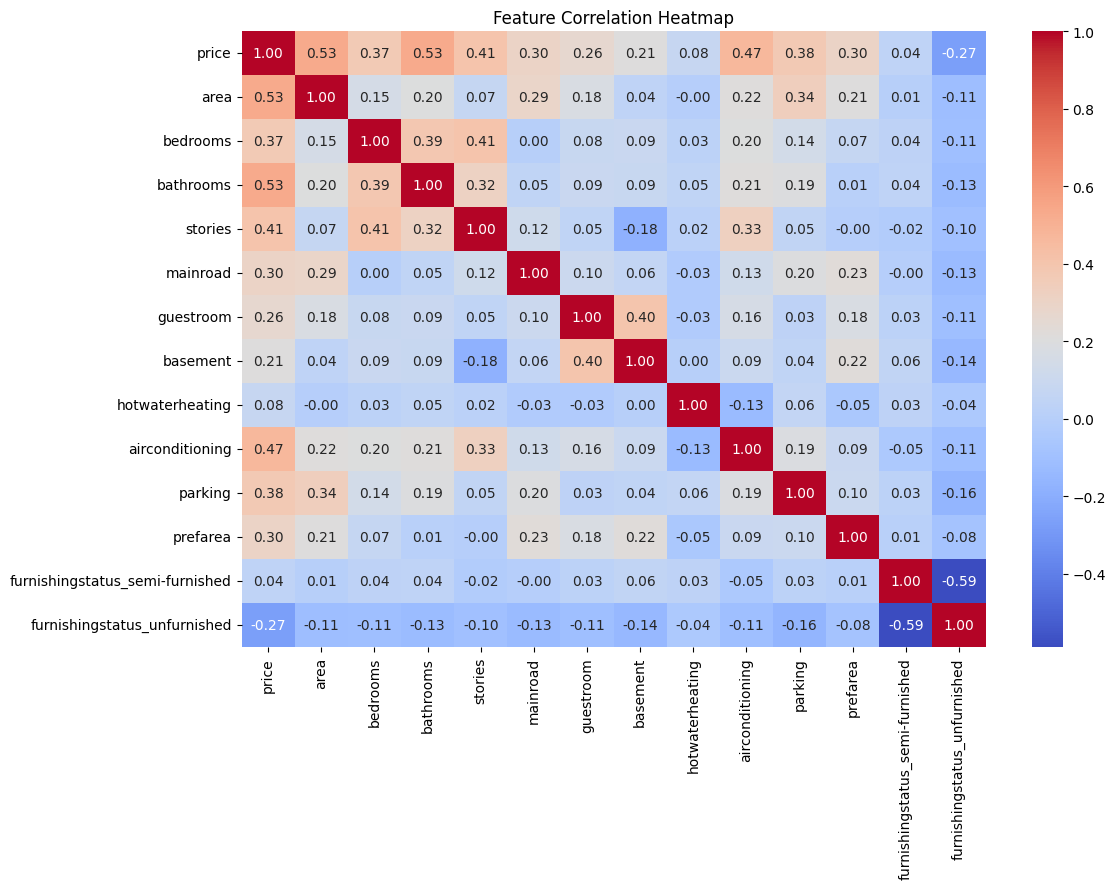

In [5]:
# Correlation Heatmap (only numeric columns)
plt.figure(figsize=(12,8))
numeric_types = training_set.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_types.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# model training

In [8]:
X_train = training_set.drop('price', axis=1)
y_train = training_set['price']

In [9]:
testing_set = pd.read_csv(PATH_RAW_TESTING_DATASET)
testing_set = preprocess(dataset=testing_set)

X_test = testing_set.drop('price', axis=1)
y_test = testing_set['price']

Categorical Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [10]:
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Predict on test data
y_pred = model.predict(X_test)

# evaluation

In [14]:
print("Root Mean Squared Error (RMSE) : ", root_mean_squared_error(y_test,y_pred))
print("R-squared Score (R²):",r2_score(y_test,y_pred))

Root Mean Squared Error (RMSE) :  1344827.341544803
R-squared Score (R²): 0.6421930074334262


In [15]:
print("intercept :", model.intercept_)
print("coeffiecents :", model.coef_)

intercept : 4706527.385321101
coeffiecents : [ 519552.41633999   57349.55941862  521879.02774805  349251.43890557
  128498.62821472   88768.66768638  187067.80321388  149862.70299085
  365157.39385091  192005.95366749  266656.3519933   -62837.32186493
 -192015.91798221]


In [21]:
pd.DataFrame({
    'Feature': training_set.drop('price', axis=1).columns,
    'Weights':np.round(model.coef_)
    })

,Feature,Weights
0,area,519552.0
1,bedrooms,57350.0
2,bathrooms,521879.0
3,stories,349251.0
4,mainroad,128499.0
5,guestroom,88769.0
6,basement,187068.0
7,hotwaterheating,149863.0
8,airconditioning,365157.0
9,parking,192006.0


In [20]:
training_set.drop('price', axis=1).columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')